<a href="https://colab.research.google.com/github/NickKar30/GM-HSE-AI-masters-course/blob/main/Hometasks/Base/GenDL_HT1_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание - 1 (базовая группа)

В этом домашнем задании вы потренируетесь решать задачу speech-to-text.

Вы не будете тренировать сложную архитектуру с нуля, а попробуете решить эту задачу, пройдя по пайплайну, в котором задача разбита на несколько простых шагов.

- В этом задании мы призываем вас по-максимуму использовать документацию моделей и получить опыт написания кода без заготовок

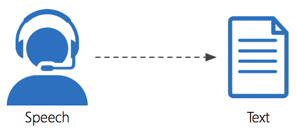

In [1]:
# !pip3 install evaluate -q

## Шаг 1 (1 балл)

* Возьмите датасет https://disk.yandex.ru/d/v2Hipv7XG4fEDQ, содержащий русскоязычные аудиозаписи

* Примените модель [whisper-small](https://huggingface.co/openai/whisper-small) из HF для определения сказанного в аудио.

* Выведите результат работы модели для 10 случайных аудио из датасета

Не стесняйтесь пользоваться документацией и источниками знаний из интернета!

In [1]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from datasets import Dataset
from huggingface_hub import HfApi, login
import pandas as pd
import torch
import torchaudio
import requests
import random
import os
from tqdm import tqdm

In [9]:
def load_urls_from_file(file_path):
    """Загрузка URL из файла urls_normalized.tsv"""
    urls = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and line.startswith('http'):
                urls.append(line)
    return urls

def download_audio_files(urls, output_folder="audio_files", max_files=None):
    """ Скачивает аудиофайлы по URL в указанную папку """
    # cоздаем папку
    os.makedirs(output_folder, exist_ok=True)
    
    # ограничиваем количество файлов
    if max_files and max_files < len(urls):
        urls = urls[:max_files]
        print(f"установим {max_files} файлов")
    
    downloaded_files = []
    failed = 0
    
    for i, url in enumerate(tqdm(urls, desc="Скачивание")):
        try:
            # ген имя файла
            filename = f"audio_{i+1:03d}.wav"
            file_path = os.path.join(output_folder, filename)
            
            # проверяем, не существует ли уже файл
            if os.path.exists(file_path):
                print(f"Файл {filename} уже существует, пропускаем")
                downloaded_files.append(file_path)
                successful += 1
                continue
            
            # скачиваем файл
            response = requests.get(url)
            response.raise_for_status()
            
            # сохраняем файл
            with open(file_path, 'wb') as f:
                f.write(response.content)
            
            downloaded_files.append(file_path)
            
        except Exception as e:
            failed += 1
            print(f"Ошибка при скачивании {url}: {e}")
    
    print(f"Ошибок: {failed}")
    
    return downloaded_files

In [8]:
def apply_whisper_model(audio_files, model_name="openai/whisper-small"):
    """ Применяет модель Whisper к аудиофайлам """

    print(f"Загружаем модель {model_name}")
    
    # загрузка
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name)
    model.config.forced_decoder_ids = None
    
    print("Модель загружена")
    
    results = []
    
    print(f"\nОбрабатываем {len(audio_files)} аудиофайлов")
    
    for i, file_path in enumerate(tqdm(audio_files, desc="Транскрипция")):
        try:
            filename = os.path.basename(file_path)
            print(f"\n[{i+1}/{len(audio_files)}] Обрабатываем: {filename}")
            
            # Загружаем аудио
            wav, sr = torchaudio.load(file_path)
            
            # Ресэмплируем до 16 kHz
            if sr != 16000:
                wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)
                sr = 16000
            
            # Подготавливаем входные данные для модели
            audio_array = wav.squeeze().numpy()
            input_features = processor(audio_array, sampling_rate=sr, return_tensors="pt").input_features
            
            # Генерируем предсказания
            predicted_ids = model.generate(input_features)
            
            # Декодируем в текст
            transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
            
            results.append({
                'file_path': file_path,
                'filename': filename,
                'transcription': transcription,
                'success': True
            })
            
            print(f"Транскрипция: {transcription}")
            
        except Exception as e:
            print(f"Ошибка при обработке {file_path}: {e}")
            results.append({
                'file_path': file_path,
                'filename': os.path.basename(file_path),
                'transcription': "Ошибка транскрипции",
                'success': False
            })
    
    return results

In [19]:
# 1. Загружаем URL из файла
urls = load_urls_from_file("urls_normalized.tsv")
print(f"Загружено {len(urls)} URL из файла")

# 2. Выбираем 10 случайных URL для демонстрации
random.seed(42)
selected_urls = random.sample(urls, min(10, len(urls)))
print(f"Выбрано {len(selected_urls)} случайных URL для обработки")

# 3. Скачиваем аудиофайлы
print("Скачивание аудиофайлов")
downloaded_files = download_audio_files(selected_urls, output_folder="audio_files", max_files=10)

# 4. Применяем модель Whisper
print("Применение Модели Whisper")
transcription_results = apply_whisper_model(downloaded_files)

# 5. Вывод результатов
print("Результаты транскрипци")

for i, result in enumerate(transcription_results):
    print(f"\nФайл {i+1}:")
    print(f"Файл: {result['filename']}")
    print(f"Транскрипция: {result['transcription']}")

Загружено 100 URL из файла
Выбрано 10 случайных URL для обработки
Скачивание аудиофайлов


Скачивание:   0%|          | 0/10 [00:00<?, ?it/s]

Скачивание: 100%|██████████| 10/10 [00:00<00:00, 11069.69it/s]

Файл audio_001.wav уже существует, пропускаем
Ошибка при скачивании http://storage.mds.yandex.net:80/get-voicetoloka/1872575/eebe7151-43f7-4e5f-af3d-d7a1a3ab2197: cannot access local variable 'successful' where it is not associated with a value
Файл audio_002.wav уже существует, пропускаем
Ошибка при скачивании http://storage.mds.yandex.net:80/get-voicetoloka/1872575/fcceeeb4-5bb7-460a-853c-99c3c7bd5aef: cannot access local variable 'successful' where it is not associated with a value
Файл audio_003.wav уже существует, пропускаем
Ошибка при скачивании http://storage.mds.yandex.net:80/get-voicetoloka/1872575/3c0ebd62-2cc1-4c9c-be63-5733511a11cd: cannot access local variable 'successful' where it is not associated with a value
Файл audio_004.wav уже существует, пропускаем
Ошибка при скачивании http://storage.mds.yandex.net:80/get-voicetoloka/1872575/09c0c412-2316-4bf4-9f92-8349067de618: cannot access local variable 'successful' where it is not associated with a value
Файл audio_005.wav у

Модель загружена

Обрабатываем 10 аудиофайлов


...

Транскрипция:  Дай не трехо.

[9/10] Обрабатываем: audio_009.wav


Транскрипция:  90%|█████████ | 9/10 [00:10<00:01,  1.07s/it]

Транскрипция:  Эффект бабочки.

[10/10] Обрабатываем: audio_010.wav


Транскрипция: 100%|██████████| 10/10 [00:11<00:00,  1.13s/it]

Транскрипция:  Старший сын
Результаты транскрипци

Файл 1:
Файл: audio_001.wav
Транскрипция:  Александр Владимирович Попов

Файл 2:
Файл: audio_002.wav
Транскрипция:  Андрей Сахаров

Файл 3:
Файл: audio_003.wav
Транскрипция:  Дайон Уорвик

Файл 4:
Файл: audio_004.wav
Транскрипция:  Брюс Springsteam

Файл 5:
Файл: audio_005.wav
Транскрипция:  Coal Porter

Файл 6:
Файл: audio_006.wav
Транскрипция:  Голова ломка.

Файл 7:
Файл: audio_007.wav
Транскрипция:  Крестный отец 2

Файл 8:
Файл: audio_008.wav
Транскрипция:  Дай не трехо.

Файл 9:
Файл: audio_009.wav
Транскрипция:  Эффект бабочки.

Файл 10:
Файл: audio_010.wav
Транскрипция:  Старший сын


## Шаг 2 (1 балл)

Текст распознается с ошибками.
Попробуйте исправить ошибки с помощью готовой (предобученной) модели spell correction.

Выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели https://huggingface.co/UrukHan/t5-russian-spell.

In [11]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

def correct_spelling_errors(texts, model_name="UrukHan/t5-russian-spell"):
    """ Исправляет ошибки в текстах с помощью модели spell correction """

    print(f"Загружаем модель исправления ошибок: {model_name}")
    
    # Загрузка
    tokenizer = T5Tokenizer.from_pretrained(model_name)
    model = T5ForConditionalGeneration.from_pretrained(model_name)
    
    print("Модель загружена")
    
    corrected_texts = []
    
    print(f"\nИсправляем ошибки в {len(texts)} текстах")
    
    for i, text in enumerate(texts):
        try:
            print(f"\n[{i+1}/{len(texts)}] Исходный текст: {text}")
            
            # Подготавливаем текст для модели
            # формат: "исправить: <текст>"
            input_text = f"исправить: {text}"
            
            # Токенизируем
            inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
            
            # Ген исправленный текст
            with torch.no_grad():
                outputs = model.generate(
                    inputs.input_ids,
                    attention_mask=inputs.attention_mask,
                    max_length=512,
                    num_beams=4,
                    early_stopping=True
                )
            
            # декодируем
            corrected_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
            
            corrected_texts.append({
                'original': text,
                'corrected': corrected_text,
                'success': True
            })
            
            print(f"Исправленный: {corrected_text}")
            
        except Exception as e:
            print(f"Ошибка при исправлении текста: {e}")
            corrected_texts.append({
                'original': text,
                'corrected': text,  # Возвращаем исходный текст при ошибке
                'success': False
            })
    
    return corrected_texts

In [20]:
# Извлекаем тексты для исправления
texts_to_correct = []
for result in transcription_results:
    if result['success'] and result['transcription'] != "Ошибка транскрипции":
        texts_to_correct.append(result['transcription'])

# первые 10 текстов
texts_to_correct = texts_to_correct[:10]

if texts_to_correct:
    
    corrected_results = correct_spelling_errors(texts_to_correct)
    
    # вывод
    print("Результаты исправления")
    
    for i, result in enumerate(corrected_results):
        print(f"\nТекст {i+1}:")
        print(f"Исходный: {result['original']}")
        print(f"Исправленный: {result['corrected']}")


Загружаем модель исправления ошибок: UrukHan/t5-russian-spell


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Модель загружена

Исправляем ошибки в 10 текстах

[1/10] Исходный текст:  Александр Владимирович Попов
Исправленный: . исправить. Александр Владимирович Попов.

[2/10] Исходный текст:  Андрей Сахаров
Исправленный: Андрей Сахаров

[3/10] Исходный текст:  Дайон Уорвик
Исправленный: Дайон Уорвик

[4/10] Исходный текст:  Брюс Springsteam
Исправленный: Брюс. ringsteam.

[5/10] Исходный текст:  Coal Porter
Исправленный: Coal Porter

[6/10] Исходный текст:  Голова ломка.
Исправленный: Голова ломка.

[7/10] Исходный текст:  Крестный отец 2
Исправленный: Крестный отец 2

[8/10] Исходный текст:  Дай не трехо.
Исправленный: Дай не трех.

[9/10] Исходный текст:  Эффект бабочки.
Исправленный: Исправить эффект бабочки.

[10/10] Исходный текст:  Старший сын
Исправленный: Старший сын.
Результаты исправления

Текст 1:
Исходный:  Александр Владимирович Попов
Исправленный: . исправить. Александр Владимирович Попов.

Текст 2:
Исходный:  Андрей Сахаров
Исправленный: Андрей Сахаров

Текст 3:
Исходный:  Дайо

## Шаг 3 (2 балла)

Соберите данные для дообучения модели выше. Для дообучения мы предлагаем вам использовать бесплатный api Groq: https://console.groq.com/docs/quickstart

Разберитесь с тем как пользоваться api (мы немного поможем вам с этим кодом ниже) и с его помощью соберите датасет (можно в несколько запросов).

- **0.5 балла** ставится за сбор датасета размером >1000 строк и сохранение в локальный файл/файлы

- **еще 0.5 балла** ставится за [создание huggingface dataset](https://huggingface.co/docs/datasets/create_dataset) (через использование библиотек datasets и huggingface) и [сохранение собранного датасета напрямую в HuggingFace](https://huggingface.co/docs/datasets/upload_dataset)

- **еще 1 балл** ставится за сбор датасета размером >1000 строк, на котором путем дообучения получится увеличить качество исправления опечаток в поставленной задаче (см. шаг 6) по сравнению с качеством прогноза той же, но предобученной модели

P.S. Если у Вас нет VPN, то можете воспользоваться другой LLM на Ваш выбор (можно, например, этим https://ollama.com/).

здесь были ключи)

In [ ]:
# Ваш код для подключения к Groq и промпты
def create_spell_correction_dataset(num_samples=1000):
    """ Создает датасет для дообучения модели исправления ошибок (список пар) """
    from groq import Groq
    
    # инициализация
    client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
    
    # промпт
    prompt = f"""
        Создай {num_samples} примеров русских текстов с опечатками и их исправлениями.

        Формат: каждая строка должна содержать пару "текст_с_ошибками|исправленный_текст"

        Требования:
        - Тексты должны быть на русском языке
        - Опечатки должны быть реалистичными (замена букв, пропуск букв, лишние буквы)
        - Длина текстов: 10-50 слов
        - Разнообразные темы: повседневные разговоры, новости, описания
        - Не используй специальные символы кроме | для разделения
        - Не нужно пояснять, какая ошибка допущена - просто пример по формату

        Примеры:
        Приве, как дела?|Привет, как дела?
        Сегодня хршая погода|Сегодня хорошая погода
        Я иду мага зин за хлебом|Я иду в магазин за хлебом
    """

    dataset = []
    
    try:
        # запрос
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="mixtral-8x7b-32768",
            temperature=0.8
            # max_tokens=8000
        )
        
        # ответ
        content = response.choices[0].message.content
        
        # Парсим ответ
        lines = content.strip().split('\n')
        for line in lines:
            if '|' in line:
                parts = line.split('|', 1)
                if len(parts) == 2:
                    error_text = parts[0].strip()
                    correct_text = parts[1].strip()
                    
                    # Проверяем, что тексты не пустые и различаются
                    if error_text and correct_text and error_text != correct_text:
                        dataset.append({
                            'input': error_text,
                            'target': correct_text
                        })
        
        print(f"Добавлено {len(dataset)} пар текстов")
        
    except Exception as e:
        print(f"Ошибка при создании датасета: {e}")
    
    print(f"Итого создано {len(dataset)} пар текстов")
    
    return dataset

In [10]:
def save_dataset_locally(dataset, filename="spell_correction_dataset"):
    """ Сохраняет датасет в локальные файлы """
    
    # csv
    csv_filename = f"{filename}.csv"
    df = pd.DataFrame(dataset)
    df.to_csv(csv_filename, index=False, encoding='utf-8')
    print(f"Сохранено в {csv_filename}")
    
    return  csv_filename

In [11]:
def create_huggingface_dataset_and_upload(dataset, dataset_name="spell-correction-russian", username="lzora7"):
    """
    Создает HuggingFace Dataset и загружает его в Hub
    """
    print(f"Создаем HuggingFace Dataset: {dataset_name}")
    
    # Создаем Dataset
    hf_dataset = Dataset.from_list(dataset)
    
    print(f"Dataset создан: {len(hf_dataset)} образцов")
    print(f"Структура: {hf_dataset.features}")
    
    # Показываем примеры
    print(f"\nПримеры из датасета:")
    for i in range(min(3, len(hf_dataset))):
        print(f"  {i+1}. {hf_dataset[i]['input']} -> {hf_dataset[i]['target']}")
    
    # Загружаем в HuggingFace Hub
    try:
        print(f"Загружаем датасет в HuggingFace Hub...")
        
        # Формируем полное имя
        full_name = f"{username}/{dataset_name}"
        
        # Загружаем в Hub
        hf_dataset.push_to_hub(full_name)
        
        print(f"Датасет успешно загружен: https://huggingface.co/datasets/{full_name}")
        
    except Exception as e:
        print(f"Ошибка при загрузке в HuggingFace: {e}")
    
    return hf_dataset

In [12]:
# Авторизация в HuggingFace Hub
from huggingface_hub import login

if "HUGGINGFACE_HUB_TOKEN" in os.environ:
    login(token=os.environ["HUGGINGFACE_HUB_TOKEN"])
    print("Авторизация успешна")
else:
    print("Переменная окружения HUGGINGFACE_HUB_TOKEN не найдена")


Авторизация успешна


In [29]:
if "GROQ_API_KEY" in os.environ:
    
    # Создаем датасет
    dataset = create_spell_correction_dataset(num_samples=1300)
    print(f"Датасет создан: {len(dataset)} пар текстов")
    
    # Сохраняем локально
    csv_file = save_dataset_locally(dataset)
    
    # Создаем HuggingFace Dataset и публикуем
    hf_dataset = create_huggingface_dataset_and_upload(dataset)
    print('Данные выложены на HF')

else:
    print("API ключ Groq не настроен")

Добавлено 1140 пар текстов
Итого создано 1140 пар текстов
Датасет создан: 1140 пар текстов
Сохранено в spell_correction_dataset.csv
Создаем HuggingFace Dataset: spell-correction-russian
Dataset создан: 1140 образцов
Структура: {'input': Value(dtype='string', id=None), 'target': Value(dtype='string', id=None)}

Примеры из датасета:
  1. 1. Приве, как дела? -> Привет, как дела?
  2. 2. Сегодня хршая погода -> Сегодня хорошая погода
  3. 3. Я иду мага зин за хлебом -> Я иду в магазин за хлебом
Загружаем датасет в HuggingFace Hub...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


README.md:   0%|          | 0.00/305 [00:00<?, ?B/s]

Датасет успешно загружен: https://huggingface.co/datasets/lzora7/spell-correction-russian
Данные выложены на HF


Сохраните собранный датасет в файл и прикрепите сюда ссылку на него \
https://huggingface.co/datasets/lzora7/spell-correction-russian

## Шаг 4 (2 балла)

Дообучите модель выше или любую другую модель, которая вам нравится, на собранных данных и протестируйте ее на нескольких ошибочно распознанных whisper-small моделью аудио. Дообучение мы разбирали на семинаре - можете посмотреть, как мы это делали там.

Для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

- Вы можете воспользовать структурой, предложенной в ячейке ниже, а можете написать код по-своему.

In [14]:
# !pip3 install --upgrade transformers datasets

In [15]:
# !pip3 install -qU transformers==4.44.2 datasets==2.19.1 tokenizers==0.19.1

In [2]:
from datasets import Dataset
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments, AutoTokenizer, AutoModelForSeq2SeqLM

# модель
model_name = "UrukHan/t5-russian-spell"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Загружаем свой CSV с парами (input → target)
df = pd.read_csv('spell_correction_dataset.csv')
dataset = Dataset.from_pandas(df)

# токенизация
def preprocess_function(examples):
    inputs = tokenizer(examples['input'], max_length=512, truncation=True)
    targets = tokenizer(examples['target'], max_length=512, truncation=True)
    return {
        'input_ids': inputs['input_ids'],
        'attention_mask': inputs['attention_mask'],
        'labels': targets['input_ids']
    }

processed_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset.column_names)
train_test_split_result = processed_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = train_test_split_result['train']
eval_dataset = train_test_split_result['test']

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)

# Аргументы обучения
training_args = Seq2SeqTrainingArguments(
    output_dir="./fine-tuned-model",
    evaluation_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_steps=50,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=None,
    push_to_hub=False,
)

# Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

# Запускаем обучение
print("Начинаем обучение")
trainer.train()

# Сохраняем дообученную модель
print("Сохраняем модель")
trainer.save_model("./fine-tuned-model")
tokenizer.save_pretrained("./fine-tuned-model")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/1140 [00:00<?, ? examples/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Начинаем обучение


  0%|          | 0/771 [00:00<?, ?it/s]

...

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 256}


{'eval_loss': 0.14013507962226868, 'eval_runtime': 0.6629, 'eval_samples_per_second': 171.961, 'eval_steps_per_second': 43.744, 'epoch': 2.72}
{'loss': 0.0002, 'grad_norm': 0.004123507533222437, 'learning_rate': 1.564828614008942e-06, 'epoch': 2.92}


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 256}
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 256}


{'train_runtime': 162.0416, 'train_samples_per_second': 18.995, 'train_steps_per_second': 4.758, 'train_loss': 0.018143353045491643, 'epoch': 3.0}
Сохраняем модель


('./fine-tuned-model/tokenizer_config.json',
 './fine-tuned-model/special_tokens_map.json',
 './fine-tuned-model/spiece.model',
 './fine-tuned-model/added_tokens.json',
 './fine-tuned-model/tokenizer.json')

Примените дообученную модель. Как раз здесь для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

In [12]:
# Тестирование дообученной модели
# Загружаем дообученную модель
model_path = "./fine-tuned-model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# Применение модели к 10 примерам из transcription_results
test_texts = [result['transcription'] for result in transcription_results[:10]]

for i, text in enumerate(test_texts, 1):
    print(f"Исходный текст (Whisper): {text}")
    
    # Подготавливаем
    input_text = f"исправить: {text}"
    
    # Токенизируем
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
    
    # Генерируем исправленный текст
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_length=512,
            num_beams=4,
            early_stopping=True
        )
    
    # Декодируем
    corrected_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    print(f"Исправленный текст: {corrected_text}")

Исходный текст (Whisper):  Александр Владимирович Попов
Исправленный текст: Александр Владимирович Попов
Исходный текст (Whisper):  Андрей Сахаров
Исправленный текст: Андрей Сахаров
Исходный текст (Whisper):  Дайон Уорвик
Исправленный текст: Дайон Урвик
Исходный текст (Whisper):  Брюс Springsteam
Исправленный текст: Брюс
Исходный текст (Whisper):  Coal Porter
Исправленный текст: Coal Porter
Исходный текст (Whisper):  Голова ломка.
Исправленный текст: Голова ломкая
Исходный текст (Whisper):  Крестный отец 2
Исправленный текст: Крестный отец 2
Исходный текст (Whisper):  Дай не трехо.
Исправленный текст: Дай не трех
Исходный текст (Whisper):  Эффект бабочки.
Исправленный текст: Исправить эффект бабочки
Исходный текст (Whisper):  Старший сын
Исправленный текст: Старший сын


## Шаг 5 (1 балл)

Время считать метрики и возвращаться к дообучению модели по необходимости. В этом шаге мы оцениваем только выполнение задания, а не значения метрик.

a) [Здесь](https://disk.yandex.ru/d/SPJU3lCt_cMDcw) лежат правильные ответы почти на все аудио - считайте метрики только для аудио, для которых мы дали вам ответы. Посчитайте [WER](https://docs.pytorch.org/torcheval/main/generated/torcheval.metrics.WordErrorRate.html) для модели whisper-small.

б) Посчитайте WER для whisper-small + исправление опечаток предобученной моделью (модель выберите самостоятельно!)

в) Посчитайте WER для whisper-small + дообученная Вами модель (данные для дообучения и модель выберите самостоятельно!)

In [ ]:
from torcheval.metrics import WordErrorRate

In [14]:
# Подсчет WER для трёх вариантов (whisper, +pretrained, +finetuned)
import json

# Загружаем эталонные ответы (URL -> текст)
json_path = 'result_array.json'
with open(json_path, 'r', encoding='utf-8') as f:
    gt_list = json.load(f)

url_to_text = {item['url']: str(item['text']) for item in gt_list}

# формируем пары (reference, prediction) только для тех URL, где есть эталон
references, whisper_preds = [], []
used_indices = []
for i, (url, pred_obj) in enumerate(zip(selected_urls, transcription_results)):
    if url in url_to_text and pred_obj.get('success', False):
        references.append(url_to_text[url])
        whisper_preds.append(str(pred_obj.get('transcription', '')))
        used_indices.append(i)

print(f"Будет оценено {len(references)} примеров (совпавших с эталонами).")

# WER
using_torcheval = True
from torcheval.metrics.text import WordErrorRate as TorchEvalWER  # новый путь


def compute_wer(refs, hyps):
    metric = TorchEvalWER()
    metric.update(refs, hyps)
    
    return float(metric.compute())

# Вспомогательная функция для исправления текстов моделью

def correct_texts_with_model(texts, model_name_or_path, batch_size=8, max_len=256):
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name_or_path)
    device = 'mps'
  
    model.to(device)
    outputs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(
            [f"исправить: {t}" for t in batch],
            return_tensors='pt', truncation=True, padding=True, max_length=max_len
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            gen = model.generate(
                enc['input_ids'],
                attention_mask=enc.get('attention_mask'),
                max_length=max_len,
                num_beams=4,
            )
        outputs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
    return outputs


# Подсчитываем WER
wer_whisper = compute_wer(references, whisper_preds)

# Whisper + предобученная spell-correction
pretrained_model = "UrukHan/t5-russian-spell"
corrected_pretrained = correct_texts_with_model(whisper_preds, pretrained_model)
wer_pretrained = compute_wer(references, corrected_pretrained)

# Whisper + дообученная нами модель
finetuned_dir = "./fine-tuned-model"
corrected_finetuned = correct_texts_with_model(whisper_preds, finetuned_dir)
wer_finetuned = compute_wer(references, corrected_finetuned)

# вывод рез
print(f"- Whisper-small: {wer_whisper:.4f}")
print(f"- Whisper-small + предобученная spell correction: {wer_pretrained:.4f}")
print(f"- Whisper-small + дообученная spell correction: {wer_finetuned:.4f}")


Будет оценено 9 примеров (совпавших с эталонами).


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


- Whisper-small: 0.9048
- Whisper-small + предобученная spell correction: 0.9167
- Whisper-small + дообученная spell correction: 0.8571


## Шаг 6 (3 балла)

В этом шаге предлагаем вам провести максимум рисерча и экспериментов для наиболее качественного решения задачи (в бесплатном google colab, без привлечения дополнительных мощностей)

* Поищите предобученные модели, применение которых для задачи speech-to-text дает меньше опечаток (меньше WER)

* Протестируйте несколько spell-correction моделей и сделайте выводы какая из них лучше (с точки зрения WER)

* Возьмите лучшую из найденных моделей и попытайтесь улучшить ее через шаг 4, как делали ранее. Попробуйте немного изменить обучение в шаге 4, чтобы добиться еще более хороших результатов (изменить данные/гиперпараметры и т.п.) и проведите соответствующий эксперимент. Объясните почему ваша модификация шага 4 теоретически может улучшить результаты и сделайте выводы о том, получилось ли улучшить качество (если нет, то предположите почему).

In [15]:
import json

# Загрузка эталонов URL -> текст
json_path = 'result_array.json'
with open(json_path, 'r', encoding='utf-8') as f:
    gt_list = json.load(f)
url_to_ref = {item['url']: str(item['text']) for item in gt_list}

# индексы тех примеров, у которых есть эталон
eval_indices = [i for i, u in enumerate(selected_urls) if u in url_to_ref]

references = [url_to_ref[selected_urls[i]] for i in eval_indices]

# WER
_using_torcheval = True
from torcheval.metrics.text import WordErrorRate as TorchEvalWER

def compute_wer(refs, hyps):
    metric = TorchEvalWER()
    metric.update(refs, hyps)
    return float(metric.compute())

# Инференс spell-correction
def correct_texts_with_model(texts, model_name_or_path, batch_size=8, max_len = 256):
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name_or_path)
    device = 'mps'
    
    model.to(device)
    outputs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer([f"исправить: {t}" for t in batch], return_tensors='pt', truncation=True, padding=True, max_length=max_len)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            gen = model.generate(enc['input_ids'], attention_mask=enc.get('attention_mask'), max_length=max_len, num_beams=4)
        outputs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
    return outputs

# Инференс Whisper для заданного списка аудиофайлов

def transcribe_with_whisper(audio_files, model_name = "openai/whisper-small"):
    print(f"\nЗагружаем ASR модель: {model_name}")
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name)
    model.config.forced_decoder_ids = None
    predictions = []
    for file_path in audio_files:
        try:
            wav, sr = torchaudio.load(file_path)
            if sr != 16000:
                wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)
                sr = 16000
            audio_array = wav.squeeze().numpy()
            inputs = processor(audio_array, sampling_rate=sr, return_tensors="pt").input_features
            with torch.no_grad():
                pred_ids = model.generate(inputs)
            text = processor.batch_decode(pred_ids, skip_special_tokens=True)[0]
        except Exception as e:
            print(f"ASR ошибка на {os.path.basename(file_path)}: {e}")
            text = ""
        predictions.append(text)
    return predictions

asr_models = [
    "openai/whisper-small",
    "openai/whisper-medium"
]

spell_models = [
    ("UrukHan/t5-russian-spell", "pretrained"),
    ("./fine-tuned-model", "finetuned"),
    ("ai-forever/ruT5-base", "pretrained"),
    ("ai-forever/ruT5-large", "pretrained")
]

# предсказания ASR для каждого варианта
predictions_by_asr = {}

# уже посчитанные whisper-small
if 'transcription_results' in globals() and transcription_results:
    whisper_small = [str(transcription_results[i]['transcription']) if i < len(transcription_results) else '' for i in range(len(downloaded_files))]
    predictions_by_asr["openai/whisper-small"] = whisper_small

for model_name in asr_models:
    if model_name in predictions_by_asr:
        continue
    try:
        preds_all = transcribe_with_whisper(downloaded_files, model_name=model_name)
        predictions_by_asr[model_name] = preds_all
    except Exception as e:
        print(f"Пропускаем ASR {model_name} из-за ошибки: {e}")

# Подсчёт WER для голых ASR и с post-processing spell-correction
results = []

for asr_name, preds_all in predictions_by_asr.items():
    preds_subset = [preds_all[i] for i in eval_indices]

    # просто ASR
    try:
        wer_asr = compute_wer(references, preds_subset)
    except Exception as e:
        print(f"Ошибка WER для {asr_name}: {e}")
        wer_asr = None
    results.append({"asr": asr_name, "spell": "-", "spell_model": "-", "wer": wer_asr})

    # ASR + каждая spell-модель
    for spell_name, label in spell_models:
        try:
            corrected = correct_texts_with_model(preds_subset, spell_name)
            wer_spell = compute_wer(references, corrected)
            results.append({
                "asr": asr_name, 
                "spell": label,           # обучена или нет
                "spell_model": spell_name, # имя модели
                "wer": wer_spell
            })
        except Exception as e:
            print(f"Пропускаем spell {spell_name} для {asr_name}: {e}")

# вывод сводной таблицы
print(f"{'ASR':<30} {'Spell модель':<40} {'Тип':<12} {'WER':>8}")

for row in results:
    asr = row['asr']
    spell_model = row['spell_model']
    spell_type = row['spell']
    wer_val = row['wer']
    
    val = f"{wer_val:.4f}" if isinstance(wer_val, float) else "N/A"
    print(f"{asr:<30} {spell_model:<40} {spell_type:<12} {val:>8}")


Загружаем ASR модель: openai/whisper-medium


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingfa

ASR                            Spell модель                             Тип               WER
openai/whisper-small           -                                        -              0.9048
openai/whisper-small           UrukHan/t5-russian-spell                 pretrained     0.9167
openai/whisper-small           ./fine-tuned-model                       finetuned      0.8571
openai/whisper-small           ai-forever/ruT5-base                     pretrained     1.1346
openai/whisper-small           ai-forever/ruT5-large                    pretrained     1.1538
openai/whisper-medium          -                                        -              0.8571
openai/whisper-medium          UrukHan/t5-russian-spell                 pretrained     0.9167
openai/whisper-medium          ./fine-tuned-model                       finetuned      0.8182
openai/whisper-medium          ai-forever/ruT5-base                     pretrained     1.0360
openai/whisper-medium          ai-forever/ruT5-large        

Среди spell correction моделей лучшая - UrukHan/t5-russian-spell \
Cреди sppech2text лучше оказалась whisper-medium

Попробуем дообучить spell correction в связке с whisper-medium

In [ ]:
# данные
df = pd.read_csv("spell_correction_dataset.csv")

# подготовка
data = df.to_dict('records')
training_dataset = [{"input": row["input"], "target": row["target"]} for row in data]

# Дообучение
# Загружаем базовую модель
base_model_name = "UrukHan/t5-russian-spell"
tokenizer_improved = AutoTokenizer.from_pretrained(base_model_name)
model_improved = AutoModelForSeq2SeqLM.from_pretrained(base_model_name)

# Подготовка датасета
dataset_dict = {"input": [item["input"] for item in training_dataset],
                "target": [item["target"] for item in training_dataset]}
hf_dataset = Dataset.from_dict(dataset_dict)

# Токенизация
def preprocess_function(examples):
    inputs = [f"исправить: {text}" for text in examples["input"]]
    model_inputs = tokenizer_improved(inputs, max_length=256, truncation=True, padding="max_length")
    labels = tokenizer_improved(examples["target"], max_length=256, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_dataset = hf_dataset.map(preprocess_function, batched=True, remove_columns=hf_dataset.column_names)

# Новые параметры
training_args_improved = Seq2SeqTrainingArguments(
    output_dir="./fine-tuned-model-improved",
    eval_strategy="no",
    save_strategy="epoch",
    learning_rate=3e-4,          
    per_device_train_batch_size=8,  # Умень с 16
    num_train_epochs=4,           # Умень с 3
    weight_decay=0.01,
    save_total_limit=2,
    predict_with_generate=True,
    logging_steps=50,
    report_to="none",
    push_to_hub=False,
)

# Обучение
data_collator = DataCollatorForSeq2Seq(tokenizer_improved, model=model_improved)
trainer_improved = Seq2SeqTrainer(
    model=model_improved,
    args=training_args_improved,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

print("Начинаем обучение")
trainer_improved.train()

# Сохраняем улучшенную модель
model_improved.save_pretrained("./fine-tuned-model-improved")
tokenizer_improved.save_pretrained("./fine-tuned-model-improved")
print("Модель сохранена в ./fine-tuned-model-improved")

# Оценка улучшенной модели
print("\nОценка улучшенной модели на тестовых данных")

# Сравниваем три варианта на whisper-medium
test_preds = [predictions_by_asr["openai/whisper-medium"][i] for i in eval_indices]

# Без spell-correction
wer_baseline = compute_wer(references, test_preds)

# Старая модель
corrected_old = correct_texts_with_model(test_preds, "./fine-tuned-model")
wer_old = compute_wer(references, corrected_old)

# Новая улучшенная модель
corrected_improved = correct_texts_with_model(test_preds, "./fine-tuned-model-improved")
wer_improved = compute_wer(references, corrected_improved)

print("\n")
print("Результаты")
print(f"{'Whisper-medium (baseline)':<50} {wer_baseline:>10.4f} {'-':>10}")
print(f"{'Whisper-medium + старая fine-tuned модель':<50} {wer_old:>10.4f} {wer_old - wer_baseline:>+10.4f}")
print(f"{'Whisper-medium + УЛУЧШЕННАЯ модель':<50} {wer_improved:>10.4f} {wer_improved - wer_baseline:>+10.4f}")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/1140 [00:00<?, ? examples/s]

Начинаем обучение


  0%|          | 0/572 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

{'loss': 0.0009, 'grad_norm': 0.014073566533625126, 'learning_rate': 0.00014265734265734263, 'epoch': 2.1}
{'loss': 0.0004, 'grad_norm': 0.0023012894671410322, 'learning_rate': 0.00011643356643356642, 'epoch': 2.45}
{'loss': 0.0003, 'grad_norm': 0.00037127299583517015, 'learning_rate': 9.02097902097902e-05, 'epoch': 2.8}


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 256}
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.0001, 'grad_norm': 0.0188599843531847, 'learning_rate': 6.398601398601397e-05, 'epoch': 3.15}
{'loss': 0.0002, 'grad_norm': 0.0004885097732767463, 'learning_rate': 3.776223776223776e-05, 'epoch': 3.5}
{'loss': 0.0, 'grad_norm': 0.0007858604076318443, 'learning_rate': 1.1538461538461538e-05, 'epoch': 3.85}


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 256}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 256}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation 

{'train_runtime': 1094.3963, 'train_samples_per_second': 4.167, 'train_steps_per_second': 0.523, 'train_loss': 0.0267189489901424, 'epoch': 4.0}
Модель сохранена в ./fine-tuned-model-improved

Оценка улучшенной модели на тестовых данных


Результаты
Whisper-medium (baseline)                              0.8571          -
Whisper-medium + старая fine-tuned модель              0.8182    -0.0390
Whisper-medium + УЛУЧШЕННАЯ модель                     1.1111    +0.2540


Были эксперименты с уменьшением lerning_rate - привели к ухудшению качества, так как недообучалось

В итоге, уменьшен batch_size для стабильности градиентов и увеличено кол-во эпох с 3 до 4 \
В результате WER увеличился (модель переобучиласть), улучшить качество не удалось